<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Project_7_Sentiment_Analysis_using_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis using NLP - Women's Clothing Reviews

This project includes:
- Data loading and exploration
- Text preprocessing
- TF-IDF and Word2Vec embeddings
- LSTM model
- BERT model
- Evaluation metrics
- Confusion matrices
- Prediction function


# Install Required Libraries

In [2]:
!pip install transformers==4.40.2 gensim seaborn nltk -q

# Restart Runtime

In [ ]:
import os
os.kill(os.getpid(), 9)

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from transformers import BertTokenizer
from transformers import TFAutoModelForSequenceClassification

warnings.filterwarnings('ignore')

import nltk

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# Upload Dataset

In [3]:
from google.colab import files

uploaded = files.upload()

Saving women_clothing_reviews.csv.csv to women_clothing_reviews.csv.csv


# Load Dataset

In [4]:
# Dataset filename uploaded in Colab
df = pd.read_csv('women_clothing_reviews.csv.csv')

# Display first rows
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


# Explore Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
Clothing ID,0
Age,0
Title,3810
Review Text,845
Rating,0
Recommended IND,0
Positive Feedback Count,0
Division Name,14
Department Name,14


# Keep Important Columns

In [7]:
df = df[['Review Text', 'Rating']]

# Remove missing values
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)

df.head()

,Review Text,Rating
0,Absolutely wonderful - silky and sexy and comf...,4
1,Love this dress! it's sooo pretty. i happene...,5
2,I had such high hopes for this dress and reall...,3
3,"I love, love, love this jumpsuit. it's fun, fl...",5
4,This shirt is very flattering to all due to th...,5


# Create Sentiment Labels

In [8]:
def create_sentiment(rating):

    if rating >= 4:
        return 1

    elif rating == 3:
        return 0

    else:
        return -1

df['Sentiment'] = df['Rating'].apply(create_sentiment)

df.head()

,Review Text,Rating,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,1
1,Love this dress! it's sooo pretty. i happene...,5,1
2,I had such high hopes for this dress and reall...,3,0
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1
4,This shirt is very flattering to all due to th...,5,1


# Visualize Sentiment Distribution

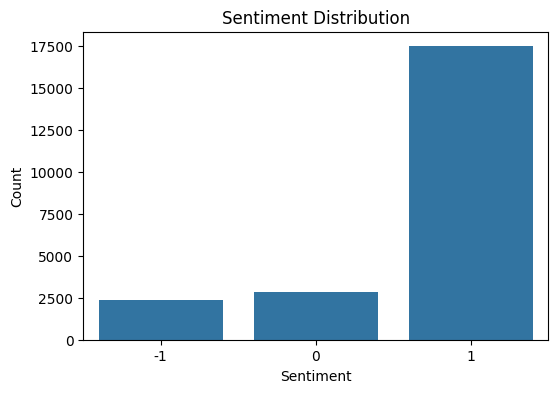

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x=df['Sentiment'])

plt.title('Sentiment Distribution')

plt.xlabel('Sentiment')

plt.ylabel('Count')

plt.show()

# Text Preprocessing

In [10]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # convert to lowercase
    text = text.lower()

    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(tokens)

df['Cleaned_Review'] = df['Review Text'].apply(preprocess_text)

df.head()

,Review Text,Rating,Sentiment,Cleaned_Review
0,Absolutely wonderful - silky and sexy and comf...,4,1,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,5,1,love dress sooo pretty happened find store im ...
2,I had such high hopes for this dress and reall...,3,0,high hope dress really wanted work initially o...
3,"I love, love, love this jumpsuit. it's fun, fl...",5,1,love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,5,1,shirt flattering due adjustable front tie perf...


# TF-IDF Feature Extraction

In [11]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['Cleaned_Review'])

print(X_tfidf.shape)

(22641, 5000)


#  Word2Vec Embeddings

In [12]:
tokenized_reviews = [
    review.split()
    for review in df['Cleaned_Review']
]

word2vec_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

# Example vector
word2vec_model.wv['dress']

array([-1.318396  , -0.02435597,  0.4916284 ,  0.2653195 , -0.2040349 ,
       -0.35313818,  0.82148117,  0.8773198 , -0.73314583, -0.9849879 ,
        0.35401577,  0.67098904,  0.32029173,  0.3378105 , -0.38603884,
       -0.28955066, -0.03530543, -0.65657794, -0.31372523, -1.1860154 ,
       -0.2335518 ,  0.20864362,  0.9136203 , -0.677304  ,  0.09506064,
        0.5166471 , -0.6958963 , -0.38438356, -0.8648124 ,  0.28292653,
        0.14228347, -0.4647089 ,  0.27124074, -0.68630075,  0.02276612,
       -0.44130617, -0.65729046,  0.2121714 , -0.08795714, -1.4178103 ,
        0.0994212 ,  0.4175653 , -0.34103206,  0.8193459 , -0.08230072,
        0.4373471 ,  0.0449636 , -0.1709137 , -0.33391893, -0.3867921 ,
        0.3194732 ,  1.0053327 , -0.48895204,  0.6032037 ,  0.02899316,
       -0.6260148 ,  0.18431132, -0.19741397, -0.4748851 ,  0.549929  ,
       -0.40369126, -0.86043715,  0.038616  , -0.00609597, -0.5856509 ,
        0.53298247,  0.56239414,  0.13524759, -0.18353674, -0.03

# Prepare Data

In [13]:
X = df['Cleaned_Review']

y = df['Sentiment']

# convert labels
label_map = {
    -1:0,
    0:1,
    1:2
}

y = y.map(label_map)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Tokenization for LSTM

In [14]:
tokenizer = Tokenizer(
    num_words=5000,
    oov_token='<OOV>'
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

max_length = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

y_train_cat = to_categorical(
    y_train,
    num_classes=3
)

y_test_cat = to_categorical(
    y_test,
    num_classes=3
)

print(X_train_pad.shape)

(18112, 100)


# Build LSTM Model

In [15]:
lstm_model = Sequential([

    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=max_length
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')

])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train LSTM Model

In [16]:
history = lstm_model.fit(
    X_train_pad,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7742 - loss: 0.7051 - val_accuracy: 0.7566 - val_loss: 0.7237
Epoch 2/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7746 - loss: 0.6980 - val_accuracy: 0.7566 - val_loss: 0.7290
Epoch 3/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7746 - loss: 0.6952 - val_accuracy: 0.7566 - val_loss: 0.7234
Epoch 4/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7746 - loss: 0.6936 - val_accuracy: 0.7566 - val_loss: 0.7248
Epoch 5/5
453/453 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7746 - loss: 0.6928 - val_accuracy: 0.7566 - val_loss: 0.7248


# Evaluate LSTM Model

In [17]:
loss, accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test_cat
)

print('LSTM Accuracy:', accuracy)

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7693 - loss: 0.6999
LSTM Accuracy: 0.7692647576332092


In [18]:
lstm_predictions = lstm_model.predict(X_test_pad)

lstm_predictions = np.argmax(
    lstm_predictions,
    axis=1
)

print(
    classification_report(
        y_test,
        lstm_predictions
    )
)

142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       457
           1       0.00      0.00      0.00       588
           2       0.77      1.00      0.87      3484

    accuracy                           0.77      4529
   macro avg       0.26      0.33      0.29      4529
weighted avg       0.59      0.77      0.67      4529



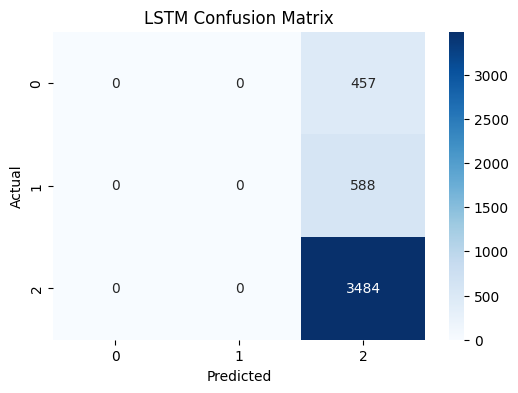

In [19]:
cm = confusion_matrix(
    y_test,
    lstm_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('LSTM Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# LSTM Accuracy Graph

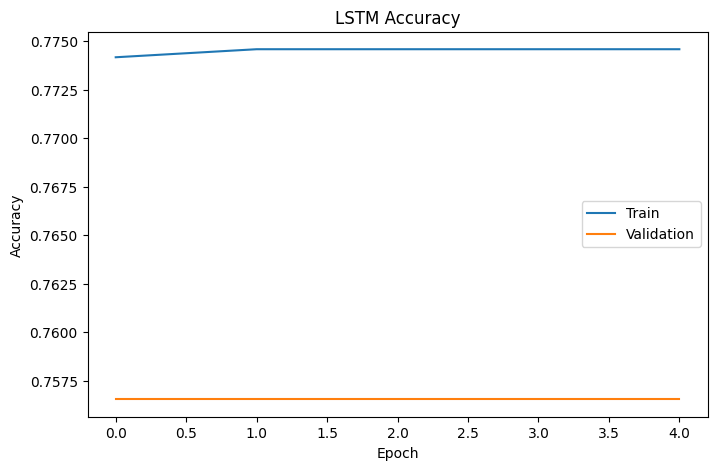

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('LSTM Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# LSTM Loss Graph

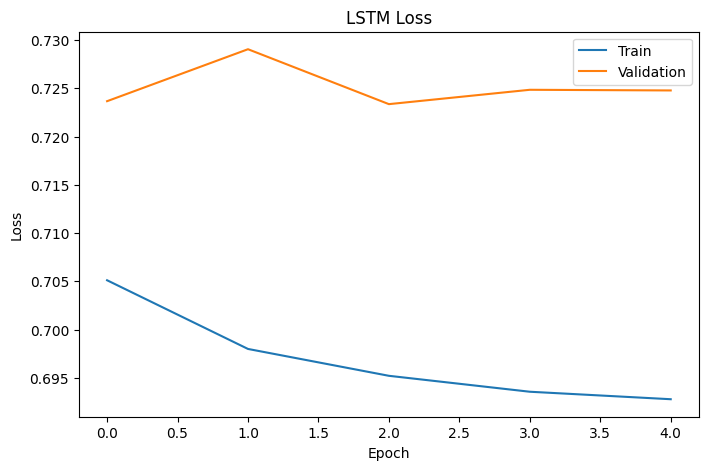

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('LSTM Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

# Load BERT Tokenizer

In [22]:
bert_tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

# Tokenize Data for BERT

In [23]:
train_encodings = bert_tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=100
)

test_encodings = bert_tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=100
)

 # Create TensorFlow Dataset

In [24]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train.values
))

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test.values
))

train_dataset = train_dataset.shuffle(1000).batch(16)

test_dataset = test_dataset.batch(16)

# Load BERT Model

In [25]:
# Load BERT model

bert_model = TFAutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# compile model
bert_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Train BERT Model

In [26]:
bert_history = bert_model.fit(
    train_dataset.take(300),
    validation_data=test_dataset.take(50),
    epochs=1
)

300/300 [==============================] - 153s 326ms/step - loss: 0.7646 - accuracy: 0.7604 - val_loss: 0.9216 - val_accuracy: 0.7713


# Evaluate BERT Model

In [27]:
bert_results = bert_model.evaluate(
    test_dataset
)

print('BERT Accuracy:', bert_results[1])

284/284 [==============================] - 27s 94ms/step - loss: 0.9318 - accuracy: 0.7693
BERT Accuracy: 0.7692647576332092


In [28]:
bert_predictions = bert_model.predict(test_dataset)

bert_labels = np.argmax(
    bert_predictions.logits,
    axis=1
)

print(
    classification_report(
        y_test,
        bert_labels
    )
)

284/284 [==============================] - 28s 91ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       457
           1       0.00      0.00      0.00       588
           2       0.77      1.00      0.87      3484

    accuracy                           0.77      4529
   macro avg       0.26      0.33      0.29      4529
weighted avg       0.59      0.77      0.67      4529



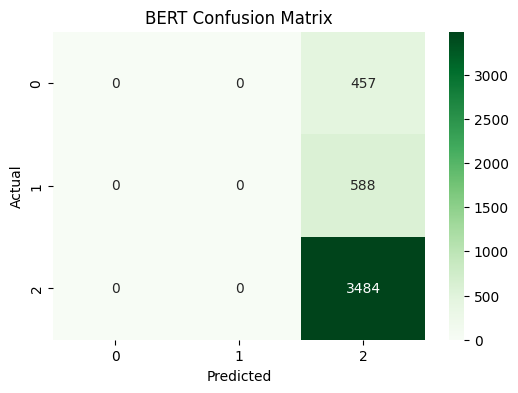

In [29]:
bert_cm = confusion_matrix(
    y_test,
    bert_labels
)

plt.figure(figsize=(6,4))

sns.heatmap(
    bert_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('BERT Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# Compare Model Performance

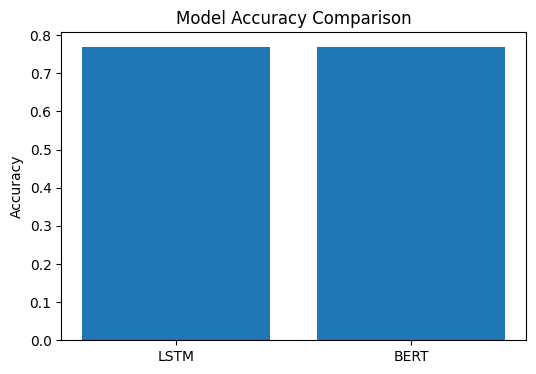

In [30]:
models = ['LSTM', 'BERT']

accuracies = [
    accuracy,
    bert_results[1]
]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')

plt.ylabel('Accuracy')

plt.show()

# Sentiment Prediction Function

In [31]:
reverse_map = {
    0:'Negative',
    1:'Neutral',
    2:'Positive'
}

def predict_sentiment(review):

    cleaned = preprocess_text(review)

    # LSTM prediction
    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        seq,
        maxlen=max_length,
        padding='post'
    )

    lstm_pred = lstm_model.predict(padded)

    lstm_label = np.argmax(
        lstm_pred,
        axis=1
    )[0]

    # BERT prediction
    bert_input = bert_tokenizer(
        review,
        return_tensors='tf',
        truncation=True,
        padding=True,
        max_length=100
    )

    bert_output = bert_model(bert_input)

    bert_label = tf.argmax(
        bert_output.logits,
        axis=1
    ).numpy()[0]

    print('Review:', review)

    print('\nLSTM Prediction:', reverse_map[lstm_label])

    print('BERT Prediction:', reverse_map[bert_label])

# Test Prediction Function

In [32]:
sample_review = 'This dress looks amazing and fits perfectly.'

predict_sentiment(sample_review)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Review: This dress looks amazing and fits perfectly.

LSTM Prediction: Positive
BERT Prediction: Positive


# Conclusion

In this project I successfully:
- cleaned text data
- applied NLP preprocessing
- implemented TF-IDF and Word2Vec
- trained an LSTM model
- fine-tuned a BERT model
- evaluated model performance
- predicted sentiment for new reviews
